# Crop Recommendation System

This notebook develops a crop recommendation system using various machine learning techniques. It analyzes soil and environmental factors to suggest the most suitable crop for a given region.

## 1. Importing Libraries

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix


import warnings
warnings.filterwarnings("ignore")

## 2. Gathering the Data

This section focuses on loading and initially inspecting the dataset used for crop recommendation.

In [2]:
dataset = pd.read_csv('dataset/Crop_recommendation.xls')
dataset.head() #Viewing the first 5 data points

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2.1. Data Fields

This section describes the features present in our dataset:

*   **N**: Ratio of Nitrogen content in the soil.
*   **P**: Ratio of Phosphorous content in the soil.
*   **K**: Ratio of Potassium content in the soil.
*   **temperature**: Temperature in degrees Celsius.
*   **humidity**: Relative humidity in percentage.
*   **ph**: pH value of the soil.
*   **rainfall**: Rainfall in millimeters.


## 3. Data Exploration and Preprocessing

This section delves into understanding the dataset's characteristics, checking for missing values, and preparing it for model training.

In [3]:
print("Shape of the data : " , dataset.shape)

Shape of the data :  (2200, 8)


In [4]:
print("Information of the data :- ")
print()
dataset.info()

Information of the data :- 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
print("Checking for Null values :-\n")
dataset.isnull().sum()

Checking for Null values :-



N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
print("Checking for duplicate datapoints :-\n")
dataset.duplicated().sum()

Checking for duplicate datapoints :-



np.int64(0)

In [7]:
print("Statistical overview of the data :-\n")
data_description = dataset.describe()
print(data_description)

# Extracting min and max values for each feature
feature_min_max = {}
for col in data_description.columns:
    feature_min_max[col] = {
        'min': data_description.loc['min', col],
        'max': data_description.loc['max', col]
    }

# You can print this dictionary to see the values
# import json
# print("\nMin/Max values for features:")
# print(json.dumps(feature_min_max, indent=4))

Statistical overview of the data :-

                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298

## 3.1. Visualizing the Data

This section uses various visualizations to understand the relationships between features and the overall distribution of the data.

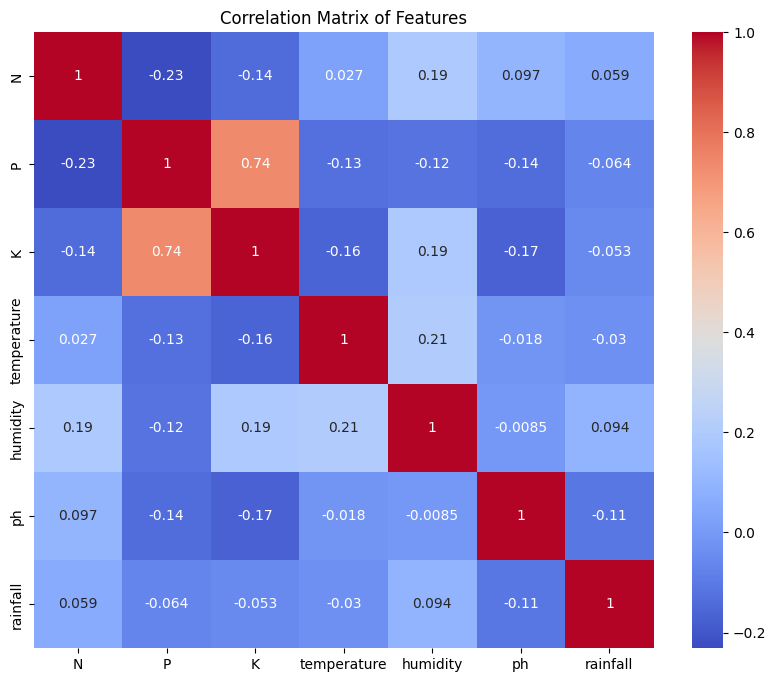

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(dataset.corr(numeric_only=True) , annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

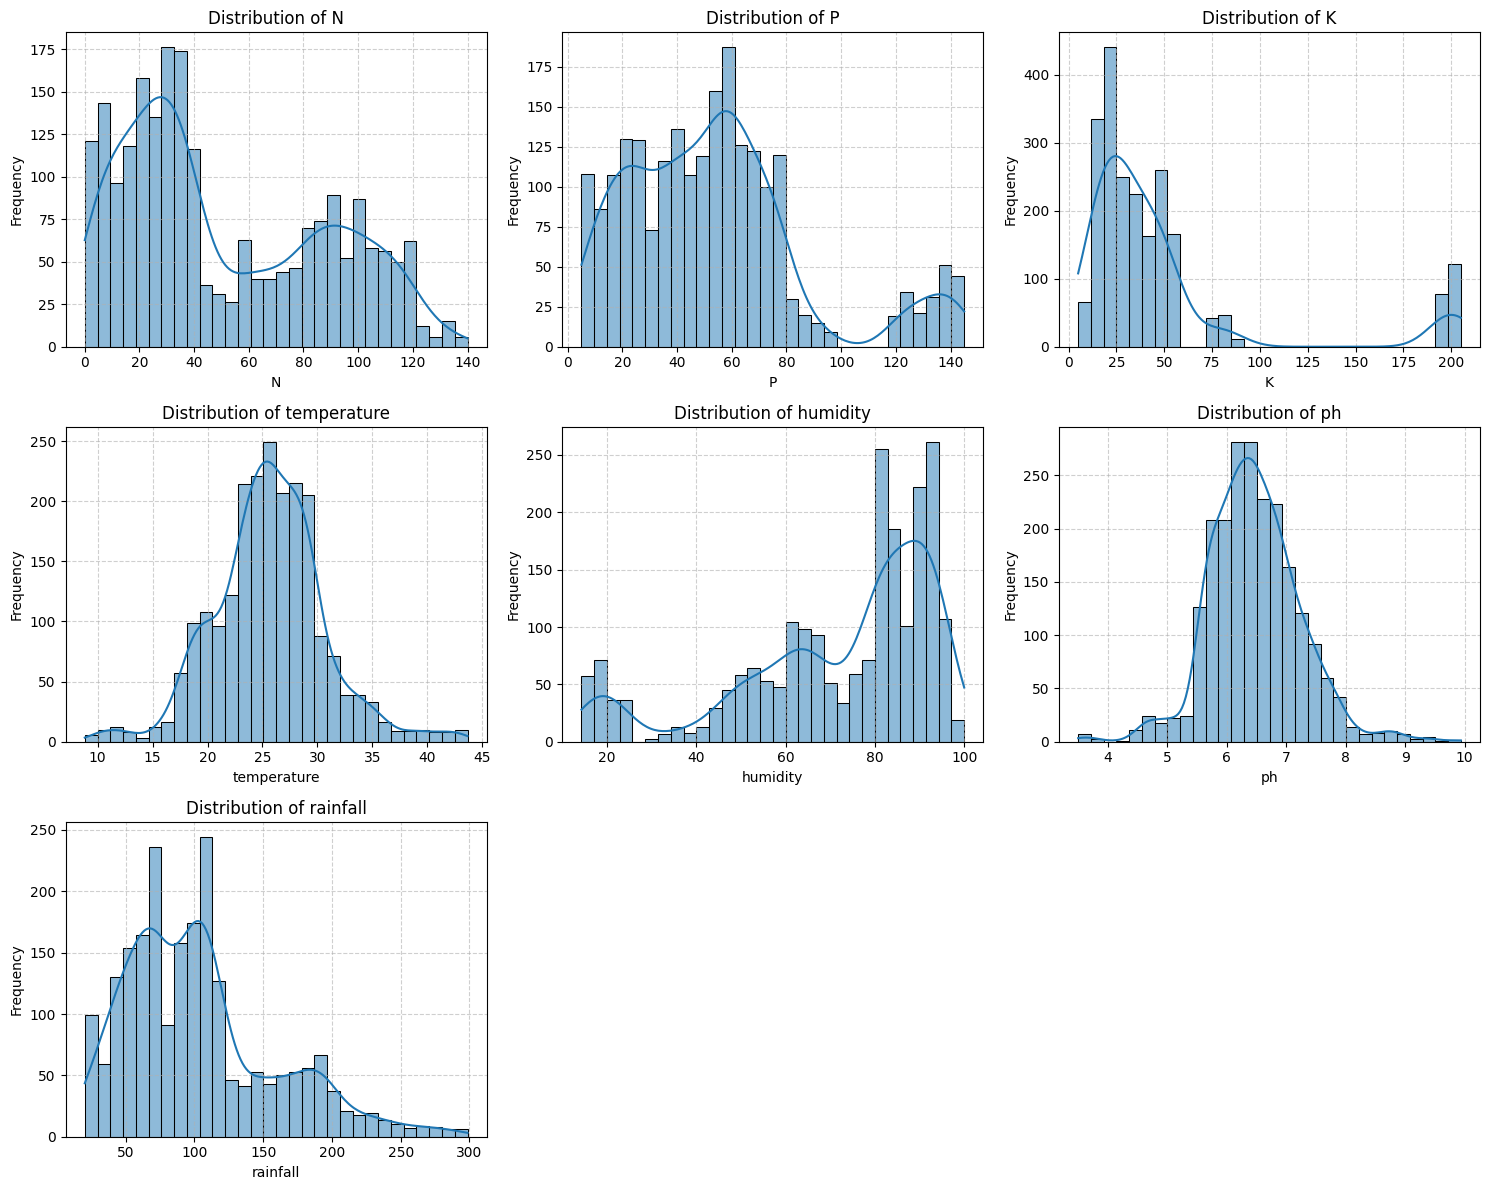

In [9]:
#Destibution of each feature 
numeric_cols = dataset.select_dtypes(include='number').columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.histplot(dataset[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

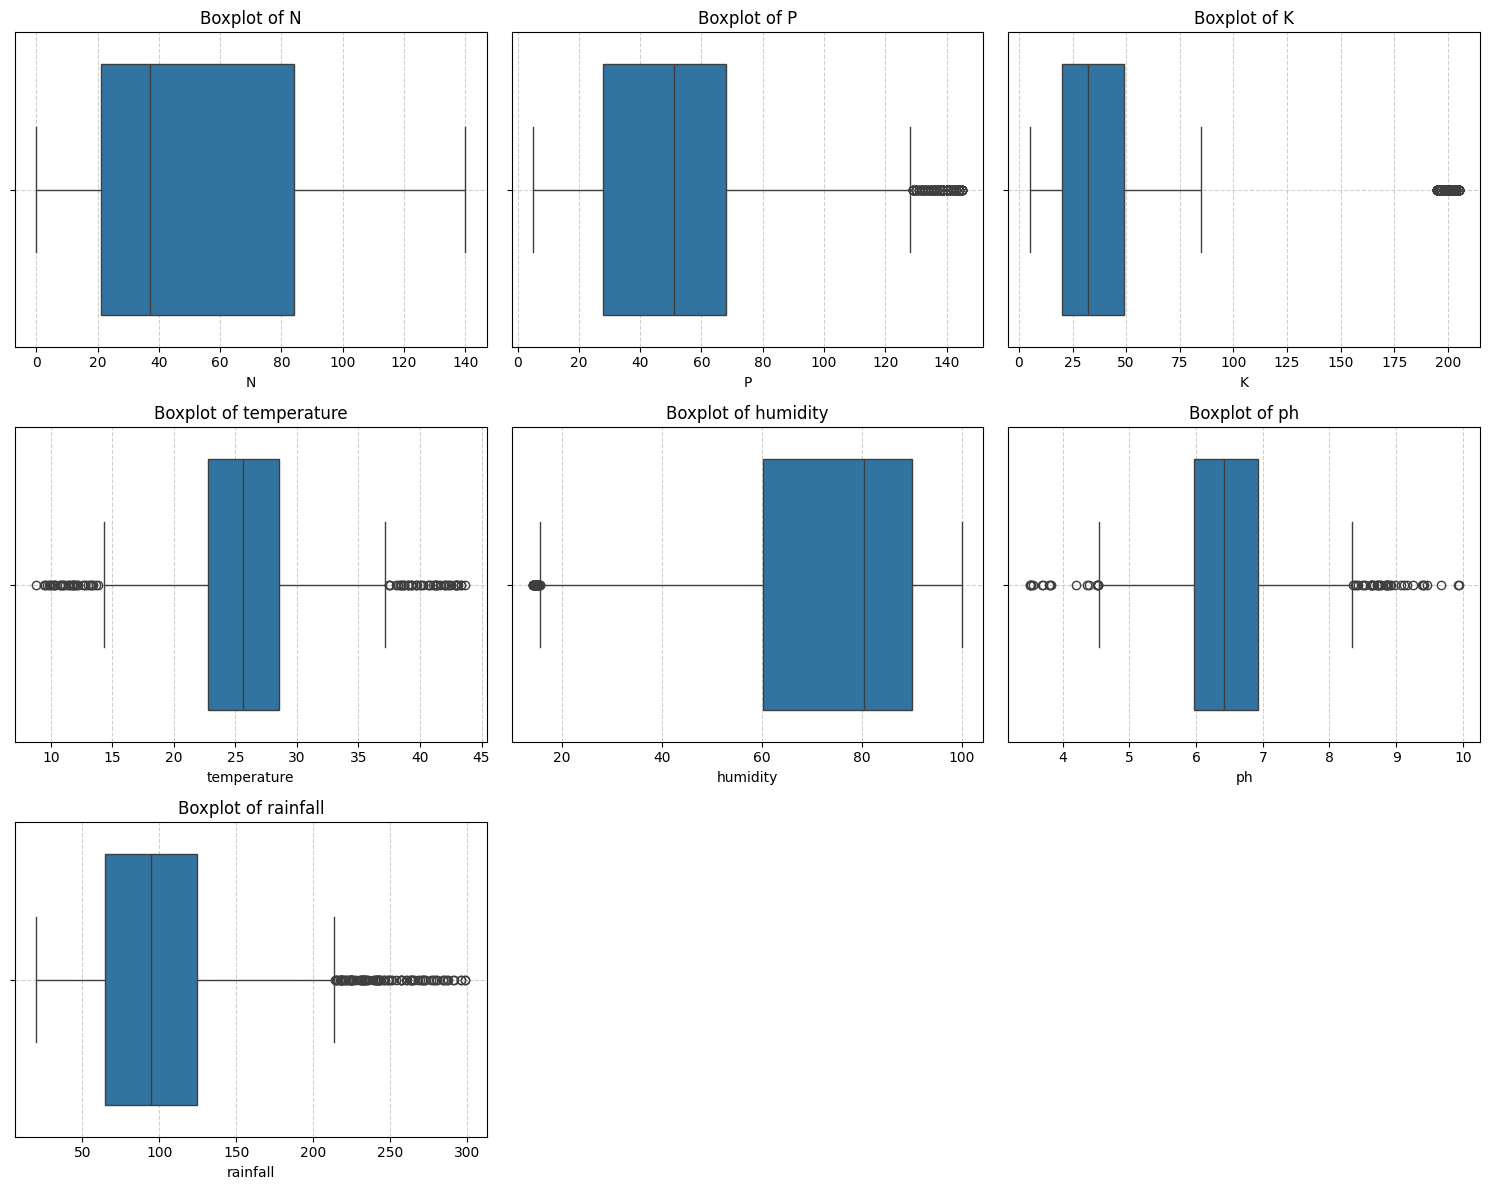

In [10]:
numeric_cols = dataset.select_dtypes(include='number').columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3.2. Encoding Categorical Data

This step converts the categorical 'label' column into a numerical format, which is required for machine learning models.

In [11]:
dataset.label.value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [12]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}

dataset['label']=  dataset['label'].map(crop_dict)


In [13]:
dataset.label.value_counts()

label
1     100
2     100
21    100
20    100
19    100
18    100
17    100
16    100
15    100
14    100
13    100
12    100
11    100
10    100
9     100
8     100
7     100
6     100
5     100
4     100
3     100
22    100
Name: count, dtype: int64

## 3.3. Splitting Data for Training and Testing

Here, the dataset is divided into training and testing sets to evaluate the model's performance on unseen data.

In [14]:
x = dataset.iloc[:, : -1]
y = dataset['label']

In [15]:
x.head(10)

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
5,69,37,42,23.058049,83.370118,7.073454,251.055000
6,69,55,38,22.708838,82.639414,5.700806,271.324860
7,94,53,40,20.277744,82.894086,5.718627,241.974195
8,89,54,38,24.515881,83.535216,6.685346,230.446236
9,68,58,38,23.223974,83.033227,6.336254,221.209196


In [16]:
y.head(10)

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: label, dtype: int64

In [17]:
print("Shape of input variable : " , x.shape)
print("shape of output variable : " , y.shape)

Shape of input variable :  (2200, 7)
shape of output variable :  (2200,)


In [18]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
print("Shape of :- \n x_train = {x_train.shape} \n x_test = {x_test.shape} \n y_train = {y_train.shape} \n y_test = {y_test.shape} ")

Shape of :- 
 x_train = {x_train.shape} 
 x_test = {x_test.shape} 
 y_train = {y_train.shape} 
 y_test = {y_test.shape} 


## 3.4. Feature Scaling

Feature scaling is applied to normalize the range of independent variables or features of the data. This step is crucial for algorithms that are sensitive to the magnitudes of input features, like many machine learning models.

We will be using `MinMaxScaler` for this purpose.

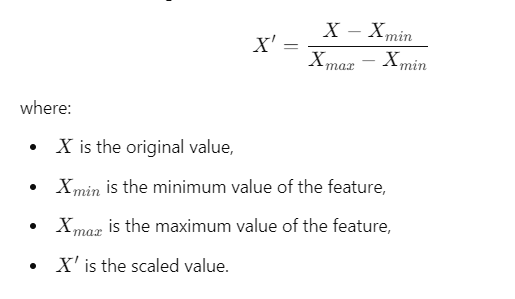

In [19]:

sc = MinMaxScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)



In [20]:
print("Scaled x_train :-\n")
x_train

Scaled x_train :-



,N,P,K,temperature,humidity,ph,rainfall
1656,17,16,14,16.396243,92.181519,6.625539,102.944161
752,37,79,19,27.543848,69.347863,7.143943,69.408782
892,7,73,25,27.521856,63.132153,7.288057,45.208411
1041,101,70,48,25.360592,75.031933,6.012697,116.553145
1179,0,17,30,35.474783,47.972305,6.279134,97.790725
...,...,...,...,...,...,...,...
1638,10,5,5,21.213070,91.353492,7.817846,112.983436
1095,108,94,47,27.359116,84.546250,6.387431,90.812505
1130,11,36,31,27.920633,51.779659,6.475449,100.258567
1294,11,124,204,13.429886,80.066340,6.361141,71.400430


In [21]:
print("Scaled x_test :-\n")
x_test

Scaled x_test :-



,N,P,K,temperature,humidity,ph,rainfall
1451,101,17,47,29.494014,94.729813,6.185053,26.308209
1334,98,8,51,26.179346,86.522581,6.259336,49.430510
1761,59,62,49,43.360515,93.351916,6.941497,114.778071
1735,44,60,55,34.280461,90.555616,6.825371,98.540477
1576,30,137,200,22.914300,90.704756,5.603413,118.604465
...,...,...,...,...,...,...,...
59,99,55,35,21.723831,80.238990,6.501698,277.962619
71,67,45,38,22.727910,82.170688,7.300411,260.887506
1908,121,47,16,23.605640,79.295731,7.723240,72.498009
1958,116,52,19,22.942767,75.371706,6.114526,67.080226


## 4. Model Training

This section focuses on selecting and training a machine learning model for crop recommendation.

In [22]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
# from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
# from sklearn.metrics import accuracy_score, confusion_matrix

# # create instances of all models
# models = {
#     'Logistic Regression': LogisticRegression(),
#     'Naive Bayes': GaussianNB(),
#     'Support Vector Machine': SVC(),
#     'K-Nearest Neighbors': KNeighborsClassifier(),
#     'Decision Tree': DecisionTreeClassifier(),
#     'Random Forest': RandomForestClassifier(),
#     'Bagging': BaggingClassifier(),
#     'AdaBoost': AdaBoostClassifier(),
#     'Gradient Boosting': GradientBoostingClassifier(),
#     'Extra Trees': ExtraTreeClassifier(),
# }

# # Dictionary to store results
# results = {}

# # Iterating over each model
# for name, model in models.items():
#     model.fit(x_train, y_train)
#     y_pred = model.predict(x_test)
#     accuracy = accuracy_score(y_test, y_pred) * 100
#     results[name] = accuracy   # store in dictionary
#     print(f"{name} with accuracy : {accuracy:.2f}%")
#     print("\n==========================================================\n")

# print("END")

In [23]:
# # Find model with highest accuracy
# best_model = max(results, key=results.get)
# best_accuracy = results[best_model]

# print(f"Best Model: {best_model} with Accuracy: {best_accuracy:.2f}%")

### 4.1. Training with Naive Bayes

Based on initial evaluation (commented out in the previous cell), the Naive Bayes algorithm showed high accuracy. We will proceed with training the model using the `GaussianNB` classifier.

In [24]:

model = GaussianNB()
model.fit(x_train_scaled , y_train)


,priors,None
,var_smoothing,1e-09


In [25]:
y_pred = model.predict(x_test_scaled)

### 4.2. Model Evaluation

After training, it's crucial to evaluate the model's performance using various metrics. Here, we'll visualize the Confusion Matrix and generate a Classification Report.

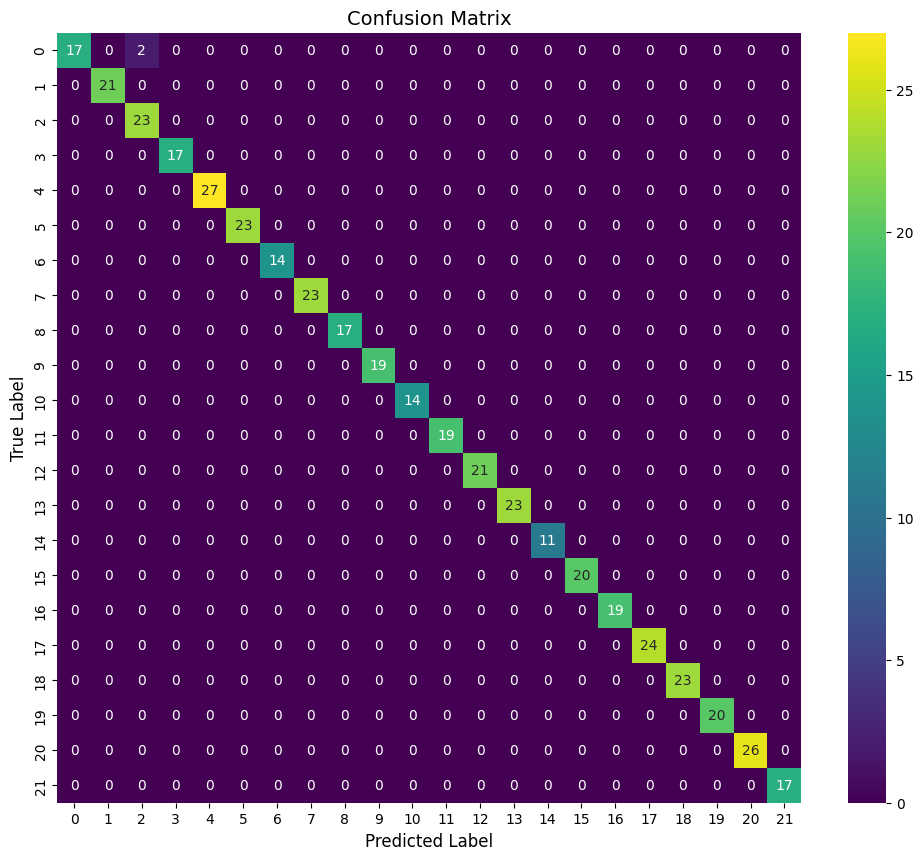

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test , y_pred) , annot=True, cmap='viridis', fmt='g')
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.show()

In [27]:
print("Classification report :- ")
print(classification_report(y_test, y_pred))

Classification report :- 
              precision    recall  f1-score   support

           1       1.00      0.89      0.94        19
           2       1.00      1.00      1.00        21
           3       0.92      1.00      0.96        23
           4       1.00      1.00      1.00        17
           5       1.00      1.00      1.00        27
           6       1.00      1.00      1.00        23
           7       1.00      1.00      1.00        14
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        17
          10       1.00      1.00      1.00        19
          11       1.00      1.00      1.00        14
          12       1.00      1.00      1.00        19
          13       1.00      1.00      1.00        21
          14       1.00      1.00      1.00        23
          15       1.00      1.00      1.00        11
          16       1.00      1.00      1.00        20
          17       1.00      1.00      1.00        19
 

In [28]:
accuracy_score(y_test, y_pred) * 100

99.54545454545455

## 5. Predictive System

This section demonstrates how to use the trained model to make predictions for new, unseen data, providing crop recommendations based on user input.

In [29]:
import pickle
import os

pickle_dir = "pickle"
os.makedirs(pickle_dir, exist_ok=True)

# Assuming 'sc' (MinMaxScaler) and 'model' (GaussianNB) are already trained in previous cells
# Save the scaler
scaler_path = os.path.join(pickle_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(sc, f)

# Save the model
model_path = os.path.join(pickle_dir, 'model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Scaler and model saved to {pickle_dir} directory.")


Scaler and model saved to pickle directory.
